*** Comparativa de modelos (Sobreajuste)***

 Árbol sin restricciones: 
Precisión en Entrenamiento: 1.00
Precisión en Prueba: 0.56

 Árbol controlado: 
Precisión en Entrenamiento: 0.74
Precisión en Prueba: 0.69
 Importancia de 'distancia_millas': 0.28
 Importancia de 'hora_salida': 0.31
 Importancia de 'mes': 0.14
 Importancia de 'dia_semana': 0.04
 Importancia de 'viento_nudos': 0.19
 Importancia de 'aerolinea_Copa': 0.02
 Importancia de 'aerolinea_Delta': 0.03


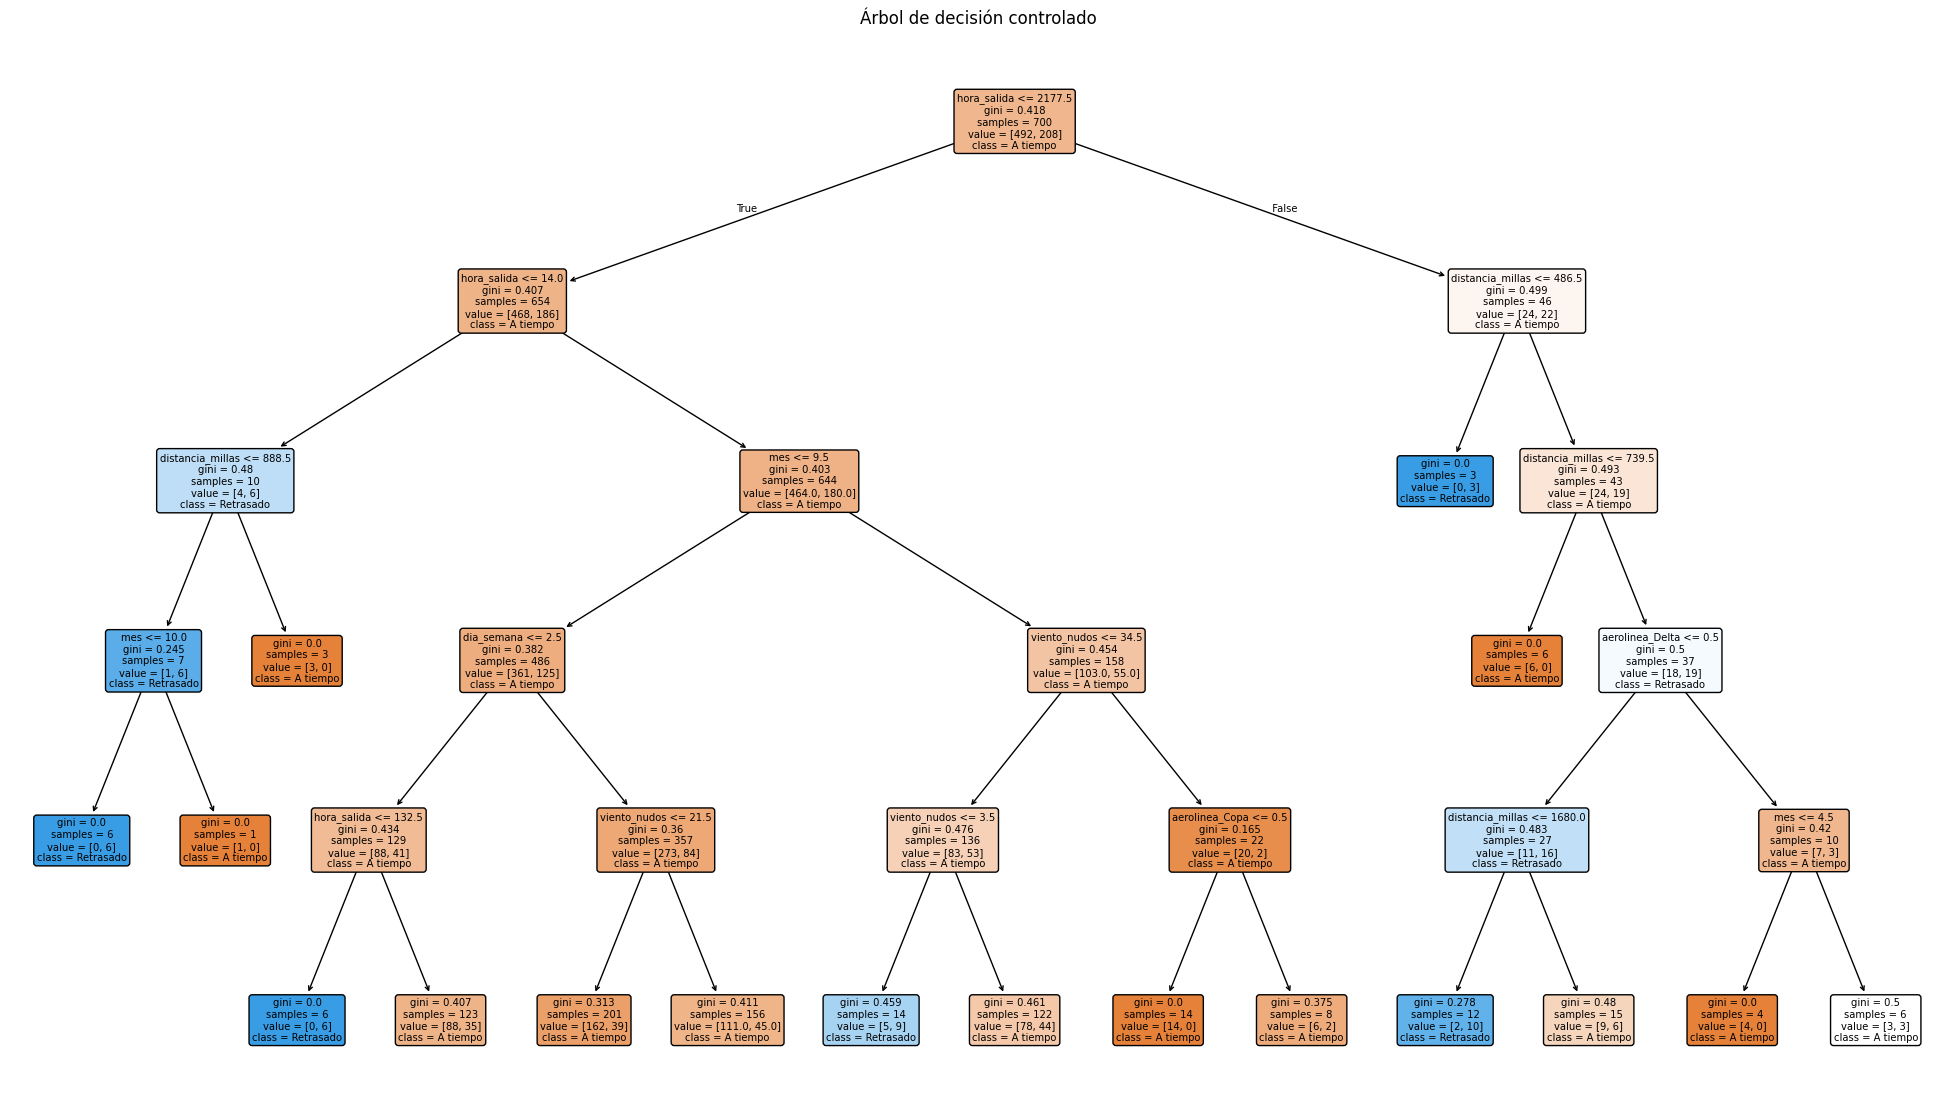

In [9]:
#Ejercicio:  ¿Se retrasará el vuelo? (comparar modelos y sobreajuste)
#usaremos un árbol de decisión (uno ajustado y otro sin resttricciones)

#importamos las librerias
import pandas as pd  # para estructurar los datos en formato de tabla (DataFrame)
import numpy as np  # para trabajar con matrices y vectores
import matplotlib.pyplot as plt  # visualización de Python
from sklearn.tree import DecisionTreeClassifier,  plot_tree # para dibujar el árbol- # DecisionTreeClassifie importa el modelo de arbol,
from sklearn.model_selection import train_test_split #función que divide los datos para entrenar y evaluar
from sklearn.metrics import accuracy_score


# 1. Simulación del conjunto de datos (de vuelos)
np.random.seed(42) # np.random: garantiza que los numeros aleatorios que se generen, sean los mismos cada vez que se corra
n_vuelos = 1000  # variable que define que se simularán 1000 registros de vuelos

datos= {  # data: diccionario de python que guarda las columnas simuladas
    'distancia_millas': np.random.randint (100,3000,n_vuelos), # np.random: garantiza que los numeros aleatorios que se generen, sean los mismos cada vez que se corra/ genera 1000 numeros enteros aleatorios entre 100 y 3000 millas
    'hora_salida': np.random.randint (0,2359,n_vuelos), # en hora militar
    'mes': np.random.randint (1,13,n_vuelos), #genera los meses del año (1-12)
    'dia_semana': np.random.randint (1,8, n_vuelos), # genera los dias de la semana (1-7)
    'viento_nudos': np.random.randint (0,40, n_vuelos), # genera los datos de velocidad simulada: 0 limite mínimo posible, 40 limite máximo ( genera números que van desde los 39 nudos: vientos fuertes)
    'aerolinea': np.random.choice(['Avianca', 'Delta', 'Copa'], size= n_vuelos), # elegirá una de las 3 aleatoriamente  para cada uno de los 1000 vuelos
    'retrasado': np.random.choice([0,1], size =n_vuelos, p = [0.7,0.3]) # elige entre 0(a iempo) y 1(retrasado) p=0.7,0.3 ordena que 70% de los vuelos sean a tiempo y 30% retrasados

}

df= pd.DataFrame (datos) # convierte los datos en una tabla estructurada (filas y columnas de pandas)

#2 cambiamos las variables de texto a números
df = pd.get_dummies(df,columns= ['aerolinea'], drop_first= True)

#3 Separamos las variables (X y y)
X= df.drop(columns= ['retrasado'])
y= df['retrasado']

#4 Dividimos el dataset en Entranamiento (train) y Prueba (test)
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size= 0.3, random_state= 42)

#5 creamos y entrenamos el árbol ( vuelo sobreajustado)
arbol_ajustado =DecisionTreeClassifier (random_state= 42) # fija el azar dentro del modelo/ numero 42 es el mas usado
arbol_ajustado.fit ( X_train, y_train)

#6 creamos y entrenamos el árbol (vuelo controlado)
#arbol_vuelo_control = DecisionTreeClassifier (max_depth=3, random_state= 42)
#arbol_vuelo_control.fit (X_train, y_train) # max_depth evita que el arbol se vuelva demasiado complejo, regla de freno de mano: solo tienes permitido un maximo de 3 preguntas par tomar una decisión.
# para ver ejecutar el arbol con 5 opciones de variables, en lugar de 3 como el de arriba
arbol_vuelo_control = DecisionTreeClassifier (max_depth=5, random_state= 42)
arbol_vuelo_control.fit (X_train, y_train)


#7 Evaluación de arbol ajustado
pred_ajustado_train = arbol_ajustado.predict (X_train) #Le pasamos las variables del conjunto de entrenamiento para ver qué opina el árbol. Guarda sus respuestas en pred_libre_train.
pred_ajustado_test = arbol_ajustado.predict (X_test)

acc_ajustado_train = accuracy_score (y_train, pred_ajustado_train) #accuracy_score(y_train, pred_libre_train): Compara las respuestas reales (y_train) contra las predicciones hechas por el modelo (pred_libre_train) y calcula la precisión del modelo
acc_ajustado_test = accuracy_score (y_test, pred_ajustado_test)

#8 Evaluación de arbol controlado
pred_control_train = arbol_vuelo_control.predict (X_train)
pred_control_test = arbol_vuelo_control.predict (X_test)

acc_control_train = accuracy_score (y_train, pred_control_train)
acc_control_test = accuracy_score (y_test, pred_control_test)

#9 visualizar los resultados:
print ("*** Comparativa de modelos (Sobreajuste)***")
print ("\n Árbol sin restricciones: ")
print(f"Precisión en Entrenamiento: {acc_ajustado_train:.2f}")
print(f"Precisión en Prueba: {acc_ajustado_test:.2f}")

print ("\n Árbol controlado: ")
print(f"Precisión en Entrenamiento: {acc_control_train:.2f}")
print(f"Precisión en Prueba: {acc_control_test:.2f}")

#10 calcular la importancia de las variables utilizadas
importancia_variables= arbol_vuelo_control.feature_importances_  #eature_importances_: Propiedad matemática nativa del árbol. Mide qué tan útil fue cada variable para reducir la incertidumbre al clasificar los vuelos. Devuelve un porcentaje para cada columna.
for nombre, imp in zip(X.columns, importancia_variables):  #Junta el nombre de cada columna con su porcentaje correspondiente para poder recorrerlos y mostrarlos con el ciclo for.

   print (f" Importancia de '{nombre}': {imp:.2f}")

#11 Visualizar el gráfico del arbol controlado
plt.figure(figsize=(25,14))
plot_tree (arbol_vuelo_control, feature_names= X.columns, class_names= ['A tiempo', 'Retrasado'], filled = True, rounded= True)
plt.title ("Árbol de decisión controlado")
plt.show()




*** Precisión del Clasificador de Vinos: ***
Precisión en Entrenamiento: 0.99
Precisión en Prueba: 0.96
*** CLasificación Detallada ( Por tipo de Vino): ***
              precision    recall  f1-score   support

     class_0       1.00      0.95      0.97        19
     class_1       0.91      1.00      0.95        21
     class_2       1.00      0.93      0.96        14

    accuracy                           0.96        54
   macro avg       0.97      0.96      0.96        54
weighted avg       0.97      0.96      0.96        54



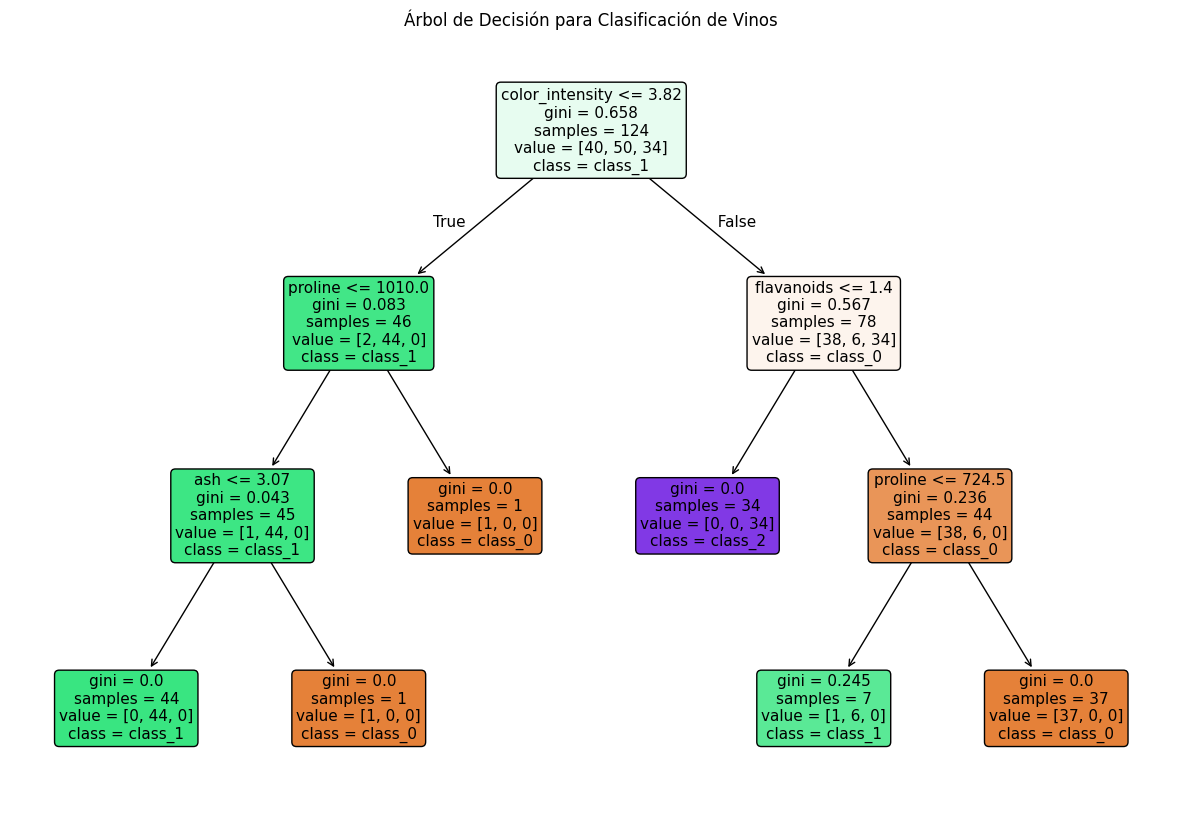

In [ ]:
#Ejercicio  · Tipos de vino (clasificación multiclase con datos reales)
# utilizaremos un conjunto de datos real e histórico muy famoso en el mundo de la Ciencia de Datos: el dataset de Vinos de Scikit-Learn (Wine dataset).
#contiene análisis químicos de 3 tipos diferentes de vino cultivados en una misma región de Italia

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report

#1 Cargamos el conjunto de datos real que existe de vio en python
datos_vino = load_wine()
#lo convertimos a DataFrame de pandas para que podamos manejarlo mejor
X = pd.DataFrame(datos_vino.data, columns = datos_vino.feature_names)
y = datos_vino.target

#2 Dividimos el Dataset en entrenamiento (70%) y Prueba (30%)
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size= 0.3, random_state= 42)

#3 Creamos y entrenamos el árbol de decisión
arbol_vino = DecisionTreeClassifier(max_depth=3, random_state= 42)
arbol_vino.fit(X_train, y_train)

#4 Evaluamos el modelo
pred_train = arbol_vino.predict(X_train)
pred_test = arbol_vino.predict(X_test)

acc_train = accuracy_score(y_train, pred_train)
acc_test = accuracy_score(y_test, pred_test)

#5 Visualizar los resultados
print("*** Precisión del Clasificador de Vinos: ***")
print(f"Precisión en Entrenamiento: {acc_train:.2f}")
print(f"Precisión en Prueba: {acc_test:.2f}")
print(f"*** CLasificación Detallada ( Por tipo de Vino): ***")
print (classification_report(y_test, pred_test, target_names= datos_vino.target_names))

#6 Visualizar el árbol
plt.figure(figsize=(15,10))
plot_tree(arbol_vino, feature_names=datos_vino.feature_names, class_names = datos_vino.target_names, filled= True, rounded= True, fontsize= 11)
plt.title("Árbol de Decisión para Clasificación de Vinos")
plt.show()

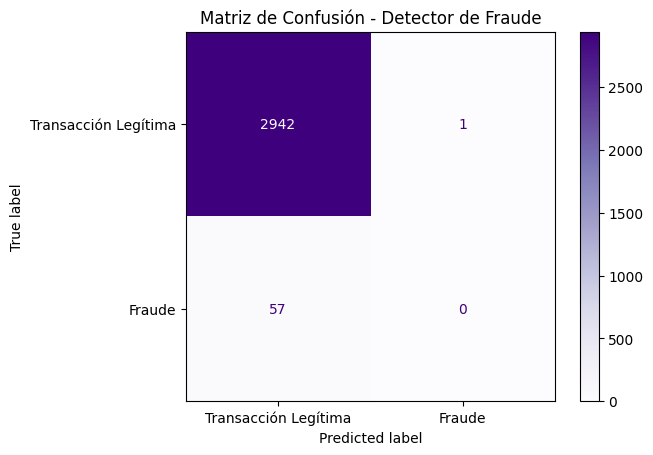

                      precision    recall  f1-score   support

Transacción Legítima       0.98      1.00      0.99      2943
              Fraude       0.00      0.00      0.00        57

            accuracy                           0.98      3000
           macro avg       0.49      0.50      0.50      3000
        weighted avg       0.96      0.98      0.97      3000



In [7]:
#Ejercicio  · Detector de fraude con tarjeta (matriz de confusión y métricas)

#importamos las librerias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns # paletas de colores predefinidas para los graficos
from sklearn.model_selection import train_test_split #divide un conjunto de datos en bloques separados
from sklearn.ensemble import RandomForestClassifier # crea un bosque de multiples árboles de decisión para decidir si una una transacción es legítima o no
from sklearn.metrics import confusion_matrix,classification_report, ConfusionMatrixDisplay # herramienta de auditoria. mide que tan bueno es el detector. calcula y muestra los aciertos y errores

#Creamos el conjunto de datos
np.random.seed(42) # para que los numeros aleatorios sean siempre los mismos cada vez que se ejecute el codigo
n_datos = 10000

monto = np.random.exponential(scale=50, size =n_datos) # genera montos de dinero de manera exponencial (muchas compras pequeñas y pocas caras)
distancia = np.random.normal (loc=10, scale=5, size = n_datos) # mide la distancia del lugar donde se encuentra el cliente y donde se hace a compra/loc=10: significa que a escogemos que a 10 km el cliente hace la compra y scale=5: radio cercano entre 5 y 15 km
si_fraude = np.random.choice([0,1], size = n_datos, p = [0.98, 0.02]) #crea la columna objetivo, configura 98% transacc legitimas y 2% sean fraude

df = pd.DataFrame({
    'Monto': monto,
    'distancia_Km': distancia,
    'Fraude': si_fraude
})
df.head()


#Separamos X y Y y dividimos los datos
X =df[['Monto', 'distancia_Km']]   #guarda en X las caracteristicas que el modelo analizará
y = df ['Fraude'] #Guarda en y la respuesta correcta ( etiqueta fraude)
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size= 0.3, random_state= 42, stratify=y) # Divide los datos en 70% para entrenar el odelo y 30% para prueba
#stratify=y: Iportante en fraudes. Asegura que el grupo de entrenamiento y el de pruebas mantengan exactamente el mismo 2% de casos de fraude.

#Entrenamos el modelo
modelo =RandomForestClassifier(random_state=42)  #Crea la estructura de clasificador de bosque aleatorio
modelo.fit(X_train, y_train)  #inicia el entrenamiento del modelo
predicciones = modelo.predict(X_test) # pedimos a modelo que intemte adivinar el resultado para los datos de prueba.

#Graficar la matriz de Confusión (nos dirá en que acertó el modelo y en que falló)
matriz = confusion_matrix(y_test, predicciones) # calcula matematicamente la matriz (calcula respuestas reales con lo que adivinó el modelo)

disp= ConfusionMatrixDisplay(confusion_matrix= matriz, display_labels= ['Transacción Legítima' , 'Fraude']) #Dibuja la matriz graficamente.
disp.plot(cmap='Purples') #dibuja la matriz con paleta de colores moradas
plt.title("Matriz de Confusión - Detector de Fraude")
plt.show()

#lectura del gráfico
#arriba izquierda: transacciones verdadras y legítimas que el modelo detectó
# arriba derecha: transacciones verdaderas y legítimas que el modelo bloqueó por error (ensó que era fraude/falta alarma)
#abajo izquierda: fraudes reales que el modelo NO detectó ( que dejó pasar)
#abajo derecha: fraudes reales que el modelo detectó y detuvo


#Para ver el reporte:
print (classification_report(y_test, predicciones, target_names = ['Transacción Legítima', 'Fraude']))
#compara los datos reales con las predicciones y genera un texto con las metricas
